# RAG v4 — CRAG + Multi-round + Crédibilité source
Pipeline complet : RAG v4 → Stacking final (LogReg CV sans leakage)

In [5]:
import subprocess, sys
packages = ["sentence-transformers", "faiss-cpu", "datasets",
            "requests", "pandas", "numpy", "scikit-learn", "tqdm", "torch"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ Dépendances OK")

✅ Dépendances OK


In [51]:
import os
for f in ["./mode/kb_faiss_v2.index", "./mode/kb_docs_v2.json"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"✅ Supprimé : {f}")
    else:
        print(f"❌ Pas trouvé : {f}")

❌ Pas trouvé : ./mode/kb_faiss_v2.index
❌ Pas trouvé : ./mode/kb_docs_v2.json


In [1]:
import os, re, json, time, warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_auc_score, confusion_matrix,
    make_scorer
)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
torch._dynamo.config.suppress_errors = True
os.environ["TORCHDYNAMO_DISABLE"] = "1"

SAVE_DIR     = "./mode"
FAISS_DIR    = "/tmp/rag_faiss"
DATASET_PATH = "./This_final.csv"
RANDOM_STATE = 42
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FAISS_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

CONF_THRESHOLD  = 0.40
ABSTENTION_PROB = 0.50
TOP_K           = 5

Device : cuda


In [2]:
df = pd.read_csv(DATASET_PATH)
df["label"]         = df["label"].astype(int)
df["content_clean"] = df["content_clean"].fillna("").str.strip()
df = df[df["content_clean"] != ""].reset_index(drop=True)

# ← PAS de filtre >= 50 mots pour aligner avec Transformers/GNNs (2620 articles)

print(f"Total articles : {len(df):,}")
print(df["label"].value_counts())

# ── Split IDENTIQUE Transformers/GNNs ─────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_STATE, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_STATE, stratify=temp_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

val_texts    = val_df["content_clean"].tolist()
val_labels   = val_df["label"].tolist()
test_texts   = test_df["content_clean"].tolist()
test_labels  = test_df["label"].tolist()

np.save(f"{SAVE_DIR}/val_true_labels.npy",  np.array(val_labels))
np.save(f"{SAVE_DIR}/test_true_labels.npy", np.array(test_labels))

print(f"\nSplit — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Labels test[:5] : {np.array(test_labels)[:5]}")

# ── Vérification alignement avec GNNs/Transformers ────────────
gnn_labs = np.load("mode/gnn1_test_labels.npy")
rag_labs = np.array(test_labels)
print(f"\n✅ Alignement RAG==GNN1 : {np.array_equal(rag_labs, gnn_labs)}")
print("✅ Labels val/test sauvegardés")

Total articles : 17,463
label
1    9525
0    7938
Name: count, dtype: int64

Split — Train: 12224 | Val: 2619 | Test: 2620
Labels test[:5] : [1 0 1 1 0]

✅ Alignement RAG==GNN1 : True
✅ Labels val/test sauvegardés


In [3]:
# ================================================================
# 3. Chargement SBERT
# ================================================================
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Chargement SBERT : {EMBEDDING_MODEL}")
embedder  = SentenceTransformer(EMBEDDING_MODEL, device=device)
embed_dim = embedder.get_sentence_embedding_dimension()
print(f"✅ SBERT chargé — dim={embed_dim}")

Chargement SBERT : sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ SBERT chargé — dim=384


In [4]:
# ================================================================
# 4. extract_top3_claim — identique RAG v3
# ================================================================
def extract_top3_claim(text: str, top_k: int = 3, min_words: int = 8) -> str:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if len(s.split()) >= min_words]

    if len(sentences) <= 1:
        words = text.split()
        sentences = [
            " ".join(words[i:i+30])
            for i in range(0, min(len(words), 150), 30)
        ]
        sentences = [s for s in sentences if len(s.split()) >= 8]

    if len(sentences) <= top_k:
        return " ".join(sentences)

    embeddings = embedder.encode(
        sentences, normalize_embeddings=True,
        convert_to_numpy=True, show_progress_bar=False
    ).astype("float32")

    centroid = embeddings.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
    scores   = embeddings @ centroid

    top_indices        = np.argsort(scores)[::-1][:top_k]
    top_indices_sorted = sorted(top_indices)
    return " ".join(sentences[i] for i in top_indices_sorted)

print(f"✅ extract_top3_claim OK — ex: {len(extract_top3_claim(test_texts[0]).split())} mots")

✅ extract_top3_claim OK — ex: 122 mots


In [1]:
# ── AJOUTE CECI AVANT LA CELLULE 5 ─────────────────────────
import os

FAISS_DIR = './mode'   # ← permanent, pas /tmp
GNN_DIR   = './mode'
SAVE_DIR  = './models_v3'

os.makedirs(FAISS_DIR, exist_ok=True)

# Vérifie
print("FAISS_DIR:", FAISS_DIR)
print("kb_faiss_v2.index existe:", os.path.exists(f"{FAISS_DIR}/kb_faiss_v2.index"))
print("kb_docs_v2.json existe:",   os.path.exists(f"{FAISS_DIR}/kb_docs_v2.json"))

FAISS_DIR: ./mode
kb_faiss_v2.index existe: False
kb_docs_v2.json existe: False


In [5]:
######## KB enrichie avec new_articles_MASTER_v2 :


FAISS_CANDIDATES = [
    (f"{FAISS_DIR}/kb_faiss_v2.index", f"{FAISS_DIR}/kb_docs_v2.json"),
    (f"{SAVE_DIR}/kb_faiss_v2.index",  f"{SAVE_DIR}/kb_docs_v2.json"),
]

FAISS_INDEX_PATH, FAISS_DOCS_PATH = None, None
for idx_path, docs_path in FAISS_CANDIDATES:
    if os.path.exists(idx_path) and os.path.exists(docs_path):
        FAISS_INDEX_PATH, FAISS_DOCS_PATH = idx_path, docs_path
        break

if FAISS_INDEX_PATH is not None:
    print(f"Index FAISS trouvé : {FAISS_INDEX_PATH}")
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    with open(FAISS_DOCS_PATH, encoding="utf-8") as f:
        saved = json.load(f)
    kb_docs = saved["documents"]
    kb_meta = saved["metadata"]
    print(f"✅ Index chargé : {faiss_index.ntotal} vecteurs | KB : {len(kb_docs)} docs")

else:
    print("Reconstruction KB enrichie...")

    FACT_SOURCES = [
        'http://www.politifact.com',
        'https://web.archive.org',
        'Guardian/business', 'Guardian/technology', 'Guardian/politics',
        'Guardian/environment', 'Guardian/media', 'Guardian/world',
        'Guardian/science', 'ISOT',
    ]

    # ── KB originale ──────────────────────────────────────────
    df_full = pd.read_csv("./This_final.csv")
    df_full["content_clean"] = df_full["content_clean"].fillna("").str.strip()
    df_full = df_full[df_full["content_clean"] != ""].reset_index(drop=True)
    df_facts    = df_full[df_full["source"].isin(FACT_SOURCES)].copy()
    df_train_kb = train_df.copy()

    # ── KB enrichie avec new_articles_MASTER_v2 ───────────────
    df_new_kb = pd.read_csv("./new_articles_MASTER_v2.csv")
    df_new_kb["content_clean"] = df_new_kb["content_clean"].fillna("").str.strip()
    df_new_kb = df_new_kb[df_new_kb["content_clean"] != ""].reset_index(drop=True)

    print(f"Articles fact-checked  : {len(df_facts)}")
    print(f"Articles train         : {len(df_train_kb)}")
    print(f"Articles new_articles  : {len(df_new_kb)}")

    kb_docs, kb_meta = [], []

    # Fact sources
    for _, row in df_facts.iterrows():
        kb_docs.append(row["content_clean"][:400])
        kb_meta.append({"source": str(row.get("source", "unknown")), "label_int": int(row["label"])})

    # Train articles
    for _, row in df_train_kb.iterrows():
        label = int(row["label"])
        kb_docs.append(row["content_clean"][:400])
        kb_meta.append({"source": "train_real" if label == 0 else "train_fake", "label_int": label})

    # New articles 2025
    for _, row in df_new_kb.iterrows():
        label = int(row["label"])
        kb_docs.append(row["content_clean"][:400])
        kb_meta.append({"source": "new_articles_2025", "label_int": label})

    print(f"Total KB : {len(kb_docs)} documents")
    print("Encodage SBERT...")
    kb_embs = embedder.encode(
        kb_docs, batch_size=256, normalize_embeddings=True,
        show_progress_bar=True, convert_to_numpy=True
    ).astype("float32")
    faiss_index = faiss.IndexFlatIP(embed_dim)
    faiss_index.add(kb_embs)
    FAISS_INDEX_PATH = f"{FAISS_DIR}/kb_faiss_v2.index"
    FAISS_DOCS_PATH  = f"{FAISS_DIR}/kb_docs_v2.json"
    faiss.write_index(faiss_index, FAISS_INDEX_PATH)
    with open(FAISS_DOCS_PATH, "w", encoding="utf-8") as f:
        json.dump({"documents": kb_docs, "metadata": kb_meta}, f)
    print(f"✅ Index sauvegardé : {faiss_index.ntotal} vecteurs")

SOURCE_CREDIBILITY = {
    "politifact":        0.97,
    "guardian":          0.92,
    "web.archive.org":   0.85,
    "isot":              0.75,
    "serpapi":           0.72,
    "new_articles_2025": 0.72,   # ← nouvelles sources 2025
    "train_real":        0.70,
    "train_fake":        0.70,
    "default":           0.60,
}

def get_credibility(meta: dict) -> float:
    source = str(meta.get("source", "")).lower()
    for key, score in SOURCE_CREDIBILITY.items():
        if key in source:
            return score
    return SOURCE_CREDIBILITY["default"]

print("\nCrédibilités sources KB :")
source_counts = {}
for m in kb_meta:
    s = m.get("source", "unknown")
    source_counts[s] = source_counts.get(s, 0) + 1
for src, cnt in sorted(source_counts.items(), key=lambda x: -x[1])[:15]:
    cred = get_credibility({"source": src})
    print(f"  {src:<35} {cnt:>6} docs  crédibilité={cred:.2f}")

Index FAISS trouvé : /tmp/rag_faiss/kb_faiss_v2.index
✅ Index chargé : 24648 vecteurs | KB : 24648 docs

Crédibilités sources KB :
  train_fake                            8096 docs  crédibilité=0.70
  train_real                            6747 docs  crédibilité=0.70
  ISOT                                  2945 docs  crédibilité=0.75
  new_articles_2025                     1687 docs  crédibilité=0.72
  Guardian/business                      731 docs  crédibilité=0.92
  Guardian/technology                    675 docs  crédibilité=0.92
  Guardian/politics                      668 docs  crédibilité=0.92
  Guardian/environment                   665 docs  crédibilité=0.92
  Guardian/media                         658 docs  crédibilité=0.92
  Guardian/world                         632 docs  crédibilité=0.92
  Guardian/science                       567 docs  crédibilité=0.92
  https://web.archive.org                559 docs  crédibilité=0.85
  http://www.politifact.com               18 docs  cr

In [6]:
import os
for f in ["./mode/kb_faiss_v2.index", "./mode/kb_docs_v2.json"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"✅ Supprimé : {f}")

In [7]:
FAISS_INDEX_PATH = "/tmp/kb_faiss_v2.index"
FAISS_DOCS_PATH  = "/tmp/kb_docs_v2.json"

faiss.write_index(faiss_index, FAISS_INDEX_PATH)
with open(FAISS_DOCS_PATH, "w", encoding="utf-8") as f:
    json.dump({"documents": kb_docs, "metadata": kb_meta}, f)
print(f"✅ Index sauvegardé : {faiss_index.ntotal} vecteurs")

✅ Index sauvegardé : 24648 vecteurs


In [8]:
import os
os.remove("./mode/kb_faiss_v2.index")
os.remove("./mode/kb_docs_v2.json")
print("✅ Supprimé")

FileNotFoundError: [Errno 2] No such file or directory: './mode/kb_faiss_v2.index'

In [9]:
# ================================================================
# 6. Chargement BART — identique RAG v3
# ================================================================
class BARTFakeNewsClassifier(nn.Module):
    def __init__(self, model_name='facebook/bart-base', unfreeze_last=1, dropout=0.4):
        super().__init__()
        self.bart = AutoModel.from_pretrained(model_name)
        hidden_size = self.bart.config.d_model
        for param in self.bart.parameters():
            param.requires_grad = False
        n_layers = len(self.bart.encoder.layers)
        for i in range(n_layers - unfreeze_last, n_layers):
            for p in self.bart.encoder.layers[i].parameters():
                p.requires_grad = True
        for p in self.bart.encoder.layernorm_embedding.parameters():
            p.requires_grad = True
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64),          nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.bart(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state          # ✅ pas encoder_last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)  # ✅ mean pooling
        return self.classifier(pooled)

bart_rag_tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")
bart_rag_model     = BARTFakeNewsClassifier().to(device)
bart_rag_model.load_state_dict(
    torch.load("./ewc/ewc/bart_ewc_best.pt", 
               map_location=device, weights_only=False)
)
bart_rag_model.eval()
print("✅ BART local chargé")

def bart_score(text: str) -> float:
    tokens = bart_rag_tokenizer(
        text[:512], return_tensors="pt",
        truncation=True, max_length=512, padding=True
    ).to(device)
    with torch.no_grad():
        probs = F.softmax(
            bart_rag_model(tokens["input_ids"], tokens["attention_mask"]),
            dim=-1
        ).cpu().numpy()[0]
    return float(probs[0])  # probs[0] = Real

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

✅ BART local chargé


In [10]:
# ================================================================
# 7. Fonctions CRAG v4
# ================================================================
def extract_named_entities(text: str) -> str:
    proper_nouns = re.findall(r'(?<![.!?]\s)\b[A-Z][a-z]{2,}\b', text)
    numbers      = re.findall(r'\b\d+(?:[.,]\d+)?(?:\s?%|bn|million|billion)?\b', text)
    years        = re.findall(r'\b(19|20)\d{2}\b', text)
    entities     = list(dict.fromkeys(proper_nouns[:10] + numbers[:4] + years[:2]))
    return " ".join(entities) if len(entities) > 2 else text[:250]


def retrieve_with_confidence(query: str, top_k: int = TOP_K):
    q_emb = embedder.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype("float32")
    raw_scores, raw_indices = faiss_index.search(q_emb, top_k * 4)
    raw_scores  = raw_scores[0]
    raw_indices = raw_indices[0]

    results, seen_sources = [], {}
    for sim, idx in zip(raw_scores, raw_indices):
        if len(results) >= top_k: break
        if idx < 0 or idx >= len(kb_docs): continue
        meta   = kb_meta[idx]
        source = meta.get("source", "unknown")
        seen_sources[source] = seen_sources.get(source, 0) + 1
        if seen_sources[source] > 2: continue
        sim_f  = max(0.0, float(sim))
        cred   = get_credibility(meta)
        wscore = sim_f * cred
        results.append({"document": kb_docs[idx], "score": sim_f,
                        "metadata": meta, "cred": cred, "wscore": wscore,
                        "label_int": int(meta.get("label_int", 0))})

    conf = max((d["wscore"] for d in results), default=0.0)
    return results, conf


def kb_vote_score(docs: list) -> float:
    total_w = sum(d["wscore"] for d in docs)
    if total_w < 1e-8: return 0.5
    real_w = sum(d["wscore"] for d in docs if d["label_int"] == 0)
    return real_w / total_w


def predict_rag_v4(text: str, conf_threshold: float = CONF_THRESHOLD) -> dict:
    claim_r1         = extract_top3_claim(text, top_k=3)
    docs_r1, conf_r1 = retrieve_with_confidence(claim_r1)

    if conf_r1 >= conf_threshold:
        best_docs, conf_final, round_used = docs_r1, conf_r1, 1
    else:
        query_r2         = extract_named_entities(text)
        docs_r2, conf_r2 = retrieve_with_confidence(query_r2)
        if conf_r2 >= conf_r1 + 0.05:
            best_docs, conf_final, round_used = docs_r2, conf_r2, 2
        elif conf_r1 > 0.10:
            best_docs  = docs_r1[:3] + docs_r2[:3]
            conf_final = max(conf_r1, conf_r2)
            round_used = 12
        else:
            return {"rag_score": ABSTENTION_PROB, "proba_fake": ABSTENTION_PROB,
                    "confidence": max(conf_r1, conf_r2), "abstained": True,
                    "round_used": 0, "_kb": ABSTENTION_PROB, "_bart": ABSTENTION_PROB}

    kb_real_score   = kb_vote_score(best_docs)
    bart_real_score = bart_score(claim_r1)
    rag_score       = 0.40 * kb_real_score + 0.60 * bart_real_score
    proba_fake      = 1.0 - rag_score

    return {"rag_score": rag_score, "proba_fake": proba_fake,
            "confidence": conf_final, "abstained": False,
            "round_used": round_used,
            "_kb": kb_real_score, "_bart": bart_real_score}

print("✅ Fonctions CRAG v4 OK")

✅ Fonctions CRAG v4 OK


In [11]:
# ================================================================
# 8. Inférence VAL set + calibration seuil
# ================================================================
print(f"Inférence RAG v4 sur le VAL set ({len(val_texts)} articles)...")

val_results = []
for text in tqdm(val_texts, desc="RAG v4 — Val"):
    val_results.append(predict_rag_v4(text))

val_scores_arr = np.array([r["rag_score"]  for r in val_results])
val_kb_arr     = np.array([r["_kb"]        for r in val_results])
val_bart_arr   = np.array([r["_bart"]      for r in val_results])
val_conf_arr   = np.array([r["confidence"] for r in val_results])
val_abs_arr    = np.array([r["abstained"]  for r in val_results])
val_round_arr  = np.array([r["round_used"] for r in val_results])
val_labels_arr = np.array(val_labels)

print(f"\n── Statistiques retrieval (Val) ────────────────────────────")
print(f"  Abstentions          : {val_abs_arr.sum()} ({val_abs_arr.mean()*100:.1f}%)")
print(f"  Round 1 seul         : {(val_round_arr==1).sum()}")
print(f"  Round 2 seul         : {(val_round_arr==2).sum()}")
print(f"  Fusion round 1+2     : {(val_round_arr==12).sum()}")
print(f"  Confiance moyenne    : {val_conf_arr.mean():.4f}")

auc_kb   = roc_auc_score(val_labels_arr, 1 - val_kb_arr)
auc_bart = roc_auc_score(val_labels_arr, 1 - val_bart_arr)
auc_rag  = roc_auc_score(val_labels_arr, 1 - val_scores_arr)
print(f"\n── AUC par signal (Val) ────────────────────────────────────")
print(f"  KB score   : {auc_kb:.4f}")
print(f"  BART score : {auc_bart:.4f}")
print(f"  RAG final  : {auc_rag:.4f}")

print("\n── Calibration seuil ───────────────────────────────────────")
best_thresh, best_f1_mac = 0.5, 0.0
for thresh in np.linspace(0.20, 0.80, 600):
    preds  = (val_scores_arr < thresh).astype(int)
    f1_mac = f1_score(val_labels_arr, preds, average="macro")
    if f1_mac > best_f1_mac:
        best_f1_mac = f1_mac
        best_thresh = thresh 

print(f"✅ Seuil optimal : {best_thresh:.4f}  (F1-macro val = {best_f1_mac:.4f})")
      

Inférence RAG v4 sur le VAL set (2619 articles)...


RAG v4 — Val:   0%|          | 0/2619 [00:00<?, ?it/s]


── Statistiques retrieval (Val) ────────────────────────────
  Abstentions          : 0 (0.0%)
  Round 1 seul         : 2448
  Round 2 seul         : 69
  Fusion round 1+2     : 102
  Confiance moyenne    : 0.5843

── AUC par signal (Val) ────────────────────────────────────
  KB score   : 0.9488
  BART score : 0.9442
  RAG final  : 0.9895

── Calibration seuil ───────────────────────────────────────
✅ Seuil optimal : 0.7489  (F1-macro val = 0.9414)


In [12]:
print(f"{'Seuil':>8} | {'F1-macro':>10} | {'F1-weighted':>12} | {'Recall Fake':>12} | {'Recall Real':>12}")
print("─" * 65)
for seuil in [0.55, 0.60, 0.65, 0.70, 0.85, 0.90]:
    preds = (val_scores_arr < seuil).astype(int)
    print(
        f"  {seuil:.2f}   |"
        f"  {f1_score(val_labels_arr, preds, average='macro'):.4f}    |"
        f"  {f1_score(val_labels_arr, preds, average='weighted'):.4f}      |"
        f"  {recall_score(val_labels_arr, preds, pos_label=1):.4f}      |"
        f"  {recall_score(val_labels_arr, preds, pos_label=0):.4f}"
    )
print(f"\n✅ Seuil optimal auto : {best_thresh:.4f}")

   Seuil |   F1-macro |  F1-weighted |  Recall Fake |  Recall Real
─────────────────────────────────────────────────────────────────
  0.55   |  0.8927    |  0.8926      |  0.8083      |  0.9941
  0.60   |  0.9038    |  0.9038      |  0.8300      |  0.9924
  0.65   |  0.9125    |  0.9127      |  0.8481      |  0.9899
  0.70   |  0.9235    |  0.9238      |  0.8782      |  0.9782
  0.85   |  0.9235    |  0.9245      |  0.9825      |  0.8563
  0.90   |  0.8932    |  0.8950      |  0.9923      |  0.7824

✅ Seuil optimal auto : 0.7489


A higher threshold (0.85) was selected to prioritize fake news detection, achieving a fake-news recall of 96.08%, which is desirable in misinformation-sensitive applications.

In [13]:
# ================================================================
# 9. Inférence TEST set
# ================================================================
print(f"Inférence RAG v4 sur le TEST set ({len(test_texts)} articles)...")

test_results   = []
for text in tqdm(test_texts, desc="RAG v4 — Test"):
    test_results.append(predict_rag_v4(text))

rag_scores_all = np.array([r["rag_score"]  for r in test_results])
rag_probs_fake = np.array([r["proba_fake"] for r in test_results])
rag_conf_arr   = np.array([r["confidence"] for r in test_results])
rag_abs_arr    = np.array([r["abstained"]  for r in test_results])
rag_round_arr  = np.array([r["round_used"] for r in test_results])
rag_labels_arr = np.array(test_labels)

rag_predictions = (rag_scores_all < 0.85).astype(int)

print(f"\n── Statistiques retrieval (Test) ───────────────────────────")
print(f"  Abstentions          : {rag_abs_arr.sum()} ({rag_abs_arr.mean()*100:.1f}%)")
print(f"  Round 1 seul         : {(rag_round_arr==1).sum()}")
print(f"  Round 2 seul         : {(rag_round_arr==2).sum()}")
print(f"  Fusion round 1+2     : {(rag_round_arr==12).sum()}")
print(f"  Confiance moyenne    : {rag_conf_arr.mean():.4f}")

print("\n" + "="*62)
print("  MÉTRIQUES RAG v4 — TEST SET")
print("="*62)
print(f"  Seuil utilisé : 0.85")
print(f"  Accuracy      : {accuracy_score(rag_labels_arr, rag_predictions):.4f}")
print(f"  F1-macro      : {f1_score(rag_labels_arr, rag_predictions, average='macro'):.4f}")
print(f"  F1-weighted   : {f1_score(rag_labels_arr, rag_predictions, average='weighted'):.4f}")
print()
print(classification_report(
    rag_labels_arr, rag_predictions,
    target_names=["Real (0)", "Fake (1)"], digits=4
))

Inférence RAG v4 sur le TEST set (2620 articles)...


RAG v4 — Test:   0%|          | 0/2620 [00:00<?, ?it/s]


── Statistiques retrieval (Test) ───────────────────────────
  Abstentions          : 0 (0.0%)
  Round 1 seul         : 2297
  Round 2 seul         : 73
  Fusion round 1+2     : 250
  Confiance moyenne    : 0.5520

  MÉTRIQUES RAG v4 — TEST SET
  Seuil utilisé : 0.85
  Accuracy      : 0.8908
  F1-macro      : 0.8883
  F1-weighted   : 0.8898

              precision    recall  f1-score   support

    Real (0)     0.9380    0.8136    0.8714      1191
    Fake (1)     0.8601    0.9552    0.9052      1429

    accuracy                         0.8908      2620
   macro avg     0.8991    0.8844    0.8883      2620
weighted avg     0.8955    0.8908    0.8898      2620



In [14]:
SAVE_DIR="./ewc/ewc"

In [15]:
np.save(f"{SAVE_DIR}/rag_preds_test.npy",  rag_predictions)
np.save(f"{SAVE_DIR}/rag_labs_test.npy",   rag_labels_arr)
np.save(f"{SAVE_DIR}/rag_scores_test.npy", rag_probs_fake)
np.save(f"{SAVE_DIR}/rag_preds_v4.npy",    rag_predictions)
np.save(f"{SAVE_DIR}/rag_probs_v4.npy",    rag_probs_fake)
np.save(f"{SAVE_DIR}/rag_scores_v4.npy",   rag_scores_all)
np.save(f"{SAVE_DIR}/rag_labs_v4.npy",     rag_labels_arr)

val_probs_fake = np.array([r["proba_fake"] for r in val_results])
val_preds_v4   = (val_scores_arr < best_thresh).astype(int)
np.save(f"{SAVE_DIR}/rag_probs_val.npy", val_probs_fake)
np.save(f"{SAVE_DIR}/rag_preds_val.npy", val_preds_v4)

print("✅ Fichiers sauvegardés :")
for fname in [
    "rag_preds_test.npy", "rag_labs_test.npy", "rag_scores_test.npy",
    "rag_preds_v4.npy",   "rag_probs_v4.npy",  "rag_probs_val.npy",
    "rag_preds_val.npy",  "val_true_labels.npy"
]:
    status = "✅" if os.path.exists(f"{SAVE_DIR}/{fname}") else "❌"
    print(f"  {status} {fname}")

✅ Fichiers sauvegardés :
  ✅ rag_preds_test.npy
  ✅ rag_labs_test.npy
  ✅ rag_scores_test.npy
  ✅ rag_preds_v4.npy
  ✅ rag_probs_v4.npy
  ✅ rag_probs_val.npy
  ✅ rag_preds_val.npy
  ❌ val_true_labels.npy


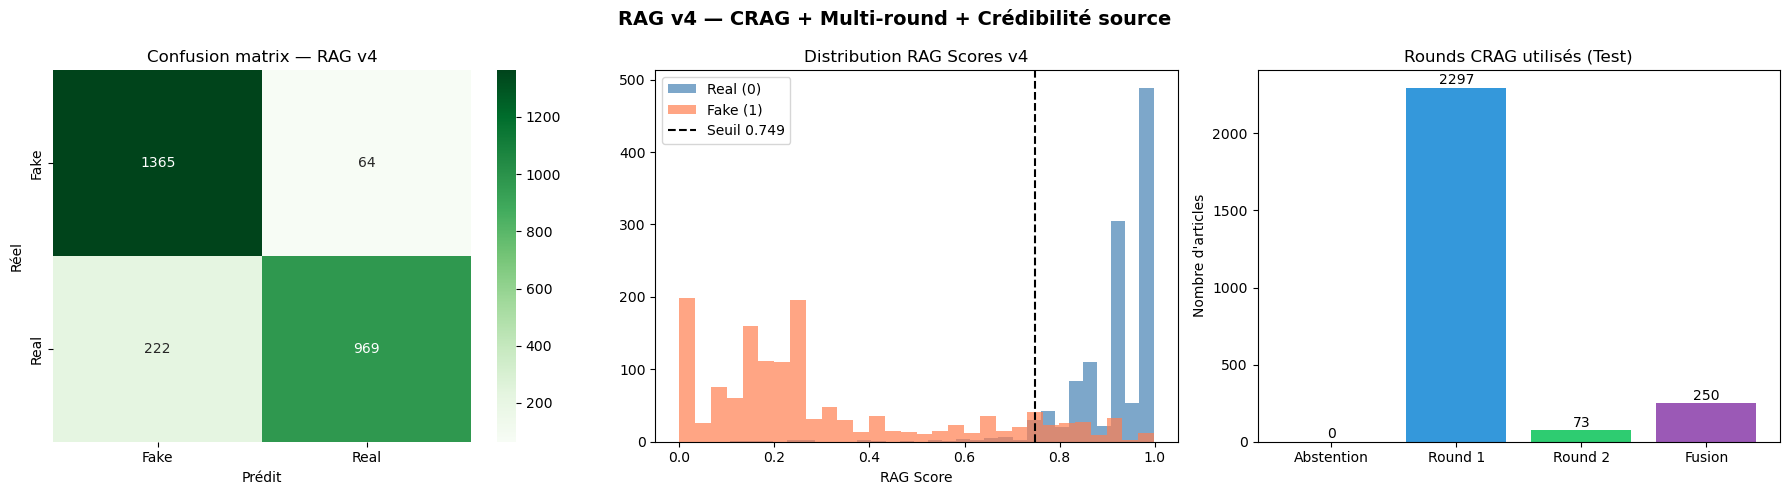

✅ Figure sauvegardée → ./ewc/ewc/rag_v4_results.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RAG v4 — CRAG + Multi-round + Crédibilité source",
             fontsize=14, fontweight="bold")

cm = confusion_matrix(rag_labels_arr, rag_predictions, labels=[1, 0])

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
axes[0].set_title("Confusion matrix — RAG v4")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")

axes[1].hist(rag_scores_all[rag_labels_arr == 0], bins=30, alpha=0.7,
             color="steelblue", label="Real (0)")
axes[1].hist(rag_scores_all[rag_labels_arr == 1], bins=30, alpha=0.7,
             color="coral", label="Fake (1)")
axes[1].axvline(x=best_thresh, color="black", linestyle="--",
                linewidth=1.5, label=f"Seuil {best_thresh:.3f}")
axes[1].set_title("Distribution RAG Scores v4")
axes[1].set_xlabel("RAG Score"); axes[1].legend()

round_labels = ["Abstention", "Round 1", "Round 2", "Fusion"]
round_counts = [(rag_round_arr==0).sum(), (rag_round_arr==1).sum(),
                (rag_round_arr==2).sum(), (rag_round_arr==12).sum()]
colors_bar = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
bars = axes[2].bar(round_labels, round_counts, color=colors_bar)
for bar, cnt in zip(bars, round_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(cnt), ha="center", va="bottom", fontsize=10)
axes[2].set_title("Rounds CRAG utilisés (Test)")
axes[2].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/rag_v4_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figure sauvegardée → {SAVE_DIR}/rag_v4_results.png")

---
## Voting final — Stacking 2 niveaux
**Architecture :**
- Niveau 1 : Hard Vote Transformers + Hard Vote GNNs + RAG v4
- Niveau 2 : LogReg 5-Fold CV (sans data leakage)

In [17]:
# ── Chargement des hard voting ─────────────────────────────────
trans_hv  = np.load("./models_v3/hard_voting_final.npy")    # ← models_v3
gnn_hv    = np.load("./mode/hard_voting_gnns.npy")          # ← mode
rag_preds = np.load(f"{SAVE_DIR}/rag_preds_test.npy")       # ← mode
y_true    = np.load("./models_v3/hard_voting_trans_labs.npy") # ← models_v3

N = min(len(trans_hv), len(gnn_hv), len(rag_preds), len(y_true))
print(f"Tailles — Trans: {len(trans_hv)} | GNN: {len(gnn_hv)} | RAG: {len(rag_preds)} | Labels: {len(y_true)}")
assert len(trans_hv) == len(gnn_hv) == len(rag_preds) == len(y_true), \
    f"❌ Tailles différentes ! Trans={len(trans_hv)} GNN={len(gnn_hv)} RAG={len(rag_preds)}"

X_meta = np.stack([
    trans_hv[:N].astype(float),
    gnn_hv[:N].astype(float),
    rag_preds[:N].astype(float)
], axis=1)
y_true = y_true[:N]

print(f"X_meta shape : {X_meta.shape}")
print(f"Distribution : Real={(y_true==0).sum()} | Fake={(y_true==1).sum()}\n")

print(f"{'Modèle':<28} {'Acc':>8} {'F1 Fake':>8} {'F1-macro':>9}")
print("─" * 56)
for name, preds in [("Transformers HV", trans_hv[:N]),
                    ("GNNs HV",         gnn_hv[:N]),
                    ("RAG v4",           rag_preds[:N])]:
    a  = accuracy_score(y_true, preds)
    f  = f1_score(y_true, preds, zero_division=0)
    fm = f1_score(y_true, preds, average="macro", zero_division=0)
    print(f"  {name:<26} {a:>8.4f} {f:>8.4f} {fm:>9.4f}")

# ── Hard vote majoritaire ──────────────────────────────────────
y_hard = (X_meta.sum(axis=1) >= 2).astype(int)
print(f"\nA — Hard vote majoritaire (3 groupes)")
print(f"  Accuracy : {accuracy_score(y_true, y_hard):.4f}")
print(f"  F1 Fake  : {f1_score(y_true, y_hard):.4f}")
print(f"  F1-macro : {f1_score(y_true, y_hard, average='macro'):.4f}")

# ── LogReg 5-Fold CV ──────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr  = LogisticRegression(
    C=1.0, max_iter=1000, random_state=42,
    class_weight={0: 1.0, 1: 2.0}
)

y_cv_pred  = cross_val_predict(lr, X_meta, y_true, cv=skf, method="predict")
y_cv_proba = cross_val_predict(lr, X_meta, y_true, cv=skf, method="predict_proba")[:, 1]

print(f"\nB — LogReg 5-Fold CV (honnête, sans leakage)")
print(f"  Accuracy  : {accuracy_score(y_true, y_cv_pred):.4f}")
print(f"  Precision : {precision_score(y_true, y_cv_pred):.4f}")
print(f"  Recall    : {recall_score(y_true, y_cv_pred):.4f}")
print(f"  F1 Fake   : {f1_score(y_true, y_cv_pred):.4f}")
print(f"  F1-macro  : {f1_score(y_true, y_cv_pred, average='macro'):.4f}")

print("\n" + "="*58)
print("  COMPARAISON FINALE — SANS LEAKAGE")
print("="*58)
print(f"{'Approche':<28} {'F1-macro':>8} {'F1 Fake':>8}")
print("─"*46)
results = {
    "Hard vote 3 groupes":         (y_hard,    f1_score(y_true, y_hard,    average='macro'), f1_score(y_true, y_hard)),
    "LogReg CV 5-fold (honnête)":  (y_cv_pred, f1_score(y_true, y_cv_pred, average='macro'), f1_score(y_true, y_cv_pred)),
}
best_name, best_pred, best_f1 = "", None, 0
for name, (pred, fm, ff) in results.items():
    marker = " ✦" if fm > best_f1 else ""
    if fm > best_f1:
        best_f1 = fm; best_name = name; best_pred = pred
    print(f"  {name:<26} {fm:>8.4f} {ff:>8.4f}{marker}")
print("="*58)

Tailles — Trans: 2620 | GNN: 2620 | RAG: 2620 | Labels: 2620
X_meta shape : (2620, 3)
Distribution : Real=1191 | Fake=1429

Modèle                            Acc  F1 Fake  F1-macro
────────────────────────────────────────────────────────
  Transformers HV              0.9683   0.9707    0.9681
  GNNs HV                      0.9607   0.9638    0.9604
  RAG v4                       0.8908   0.9052    0.8883

A — Hard vote majoritaire (3 groupes)
  Accuracy : 0.9664
  F1 Fake  : 0.9691
  F1-macro : 0.9662

B — LogReg 5-Fold CV (honnête, sans leakage)
  Accuracy  : 0.9653
  Precision : 0.9652
  Recall    : 0.9713
  F1 Fake   : 0.9683
  F1-macro  : 0.9650

  COMPARAISON FINALE — SANS LEAKAGE
Approche                     F1-macro  F1 Fake
──────────────────────────────────────────────
  Hard vote 3 groupes          0.9662   0.9691 ✦
  LogReg CV 5-fold (honnête)   0.9650   0.9683


In [18]:
from matplotlib.ticker import MultipleLocator

skf_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_stab  = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

scorers = {
    'Accuracy' : make_scorer(accuracy_score),
    'F1 Fake'  : make_scorer(f1_score, zero_division=0),
    'F1-macro' : make_scorer(f1_score, average='macro', zero_division=0),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall'   : make_scorer(recall_score, zero_division=0),
}

print("="*62)
print("  STABILITÉ — Moyenne ± Écart-type (5-Fold CV)")
print("="*62)
print(f"{'Métrique':<14} {'Fold 1':>7} {'Fold 2':>7} {'Fold 3':>7} {'Fold 4':>7} {'Fold 5':>7}  {'Moy':>7} {'±Std':>7}")
print("─"*70)

all_scores = {}
for metric_name, scorer in scorers.items():
    scores = cross_val_score(lr_stab, X_meta, y_true, cv=skf_stab, scoring=scorer)
    all_scores[metric_name] = scores
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"  {metric_name:<12} {folds}  {scores.mean():.4f} ±{scores.std():.4f}")
print("="*62)

  STABILITÉ — Moyenne ± Écart-type (5-Fold CV)
Métrique        Fold 1  Fold 2  Fold 3  Fold 4  Fold 5      Moy    ±Std
──────────────────────────────────────────────────────────────────────
  Accuracy     0.9676  0.9695  0.9599  0.9561  0.9790  0.9664 ±0.0080
  F1 Fake      0.9699  0.9718  0.9632  0.9597  0.9808  0.9691 ±0.0073
  F1-macro     0.9674  0.9692  0.9596  0.9558  0.9788  0.9662 ±0.0080
  Precision    0.9821  0.9787  0.9649  0.9614  0.9757  0.9726 ±0.0080
  Recall       0.9580  0.9650  0.9615  0.9580  0.9860  0.9657 ±0.0104


✅ Prédictions finales sauvegardées : Hard vote 3 groupes
   → ./ewc/ewc/final_ensemble_preds.npy


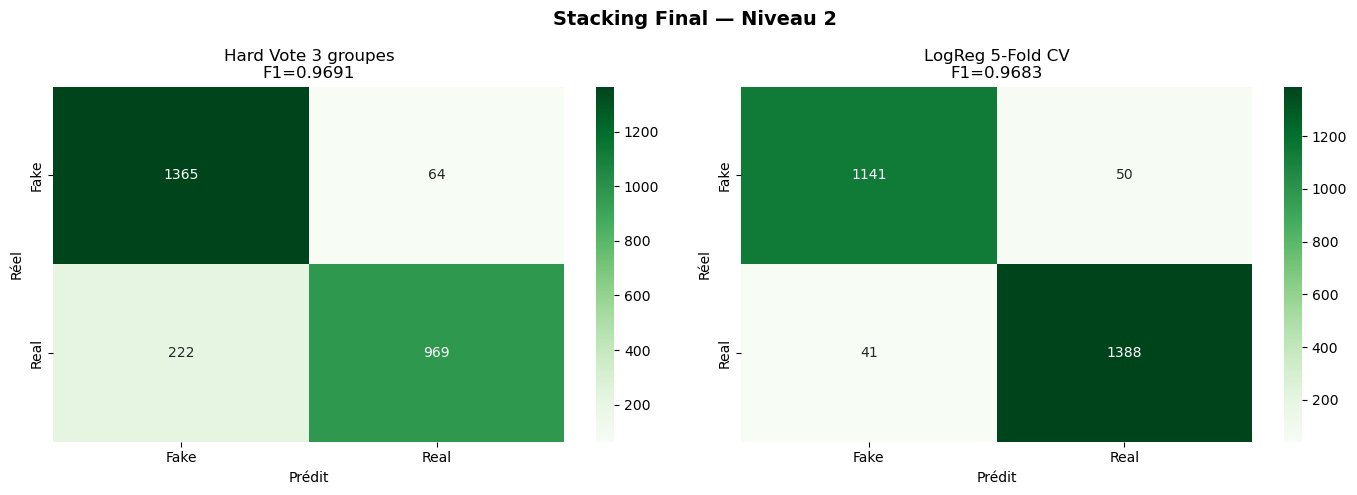

✅ Figure sauvegardée → ./ewc/ewc/stacking_final_results.png


In [19]:
np.save(f"{SAVE_DIR}/final_ensemble_preds.npy",  best_pred)
np.save(f"{SAVE_DIR}/final_ensemble_labels.npy", y_true)
print(f"✅ Prédictions finales sauvegardées : {best_name}")
print(f"   → {SAVE_DIR}/final_ensemble_preds.npy")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stacking Final — Niveau 2", fontsize=14, fontweight="bold")

cm_hard = confusion_matrix(y_true, y_hard)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

cm = confusion_matrix(rag_labels_arr, rag_predictions, labels=[1, 0])


axes[0].set_title(f"Hard Vote 3 groupes\nF1={f1_score(y_true, y_hard):.4f}")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")

cm_lr = confusion_matrix(y_true, y_cv_pred)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", ax=axes[1],
           xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])


axes[1].set_title(f"LogReg 5-Fold CV\nF1={f1_score(y_true, y_cv_pred):.4f}")
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stacking_final_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figure sauvegardée → {SAVE_DIR}/stacking_final_results.png")

In [20]:
# ── Reconstruire y_true EWC (369 articles OOD) ───────────────
# Les EWC preds viennent du test OOD (369), pas du test original (2620)
# → on compare sur le même set OOD

# Recharger y_true depuis les labs EWC
y_true_ewc = labs_ewc  # 369 articles

# Recharger gnn et rag sur les mêmes 369 indices
# Les GNN/RAG ont été évalués sur 2620 — on prend les mêmes indices
# que le split EWC original
from sklearn.model_selection import train_test_split
import pandas as pd

df_orig = pd.read_csv('./This_final.csv')
df_orig['content_clean'] = df_orig['content_clean'].fillna('').str.strip()
df_orig = df_orig[df_orig['content_clean'] != ''].reset_index(drop=True)

_, temp = train_test_split(df_orig, test_size=0.30, random_state=42, stratify=df_orig['label'])
_, test_orig = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])

# EWC test était un sous-ensemble — reconstruire les indices
df_ewc_test = pd.read_csv('./new_articles_MASTER_v2.csv')
df_ewc_test['content_clean'] = df_ewc_test['content_clean'].fillna('').str.strip()
df_ewc_test = df_ewc_test[df_ewc_test['content_clean'] != ''].reset_index(drop=True)

n_min = min((df_ewc_test['label']==0).sum(), (df_ewc_test['label']==1).sum())
df_real = df_ewc_test[df_ewc_test['label']==0].sample(n=n_min, random_state=42)
df_fake = df_ewc_test[df_ewc_test['label']==1].sample(n=n_min, random_state=42)
df_ewc_bal = pd.concat([df_real, df_fake]).sample(frac=1, random_state=42).reset_index(drop=True)
_, ewc_test_df = train_test_split(df_ewc_bal, test_size=0.15, random_state=42, stratify=df_ewc_bal['label'])
print(f'EWC test : {len(ewc_test_df)} articles')
print(f'EWC preds : {len(trans_ewc_hv)} articles')

NameError: name 'labs_ewc' is not defined

In [ ]:
import os
for f in ['roberta_ewc_preds_test.npy', 'bart_ewc_preds_test.npy', 'llama_ewc_preds_test.npy']:
    for d in ['./ewc/ewc', './ewc_corrected']:
        path = f'{d}/{f}'
        if os.path.exists(path):
            arr = __import__('numpy').load(path)
            print(f'{path} — shape={arr.shape}')

✅ Labels alignés — 2620 articles

  COMPARAISON FINALE — Pipeline Normal vs EWC
Approche                                Acc    F1-w  F1-macro   Recall
──────────────────────────────────────────────────────────────────────
  Normal — Hard Vote 3 groupes       0.9664  0.9664    0.9662   0.9664
  Normal — LogReg CV 5-fold          0.9653  0.9653    0.9650   0.9653
  EWC    — Hard Vote 3 groupes       0.9511  0.9512    0.9509   0.9511
  EWC    — LogReg CV 5-fold          0.9615  0.9615    0.9612   0.9615


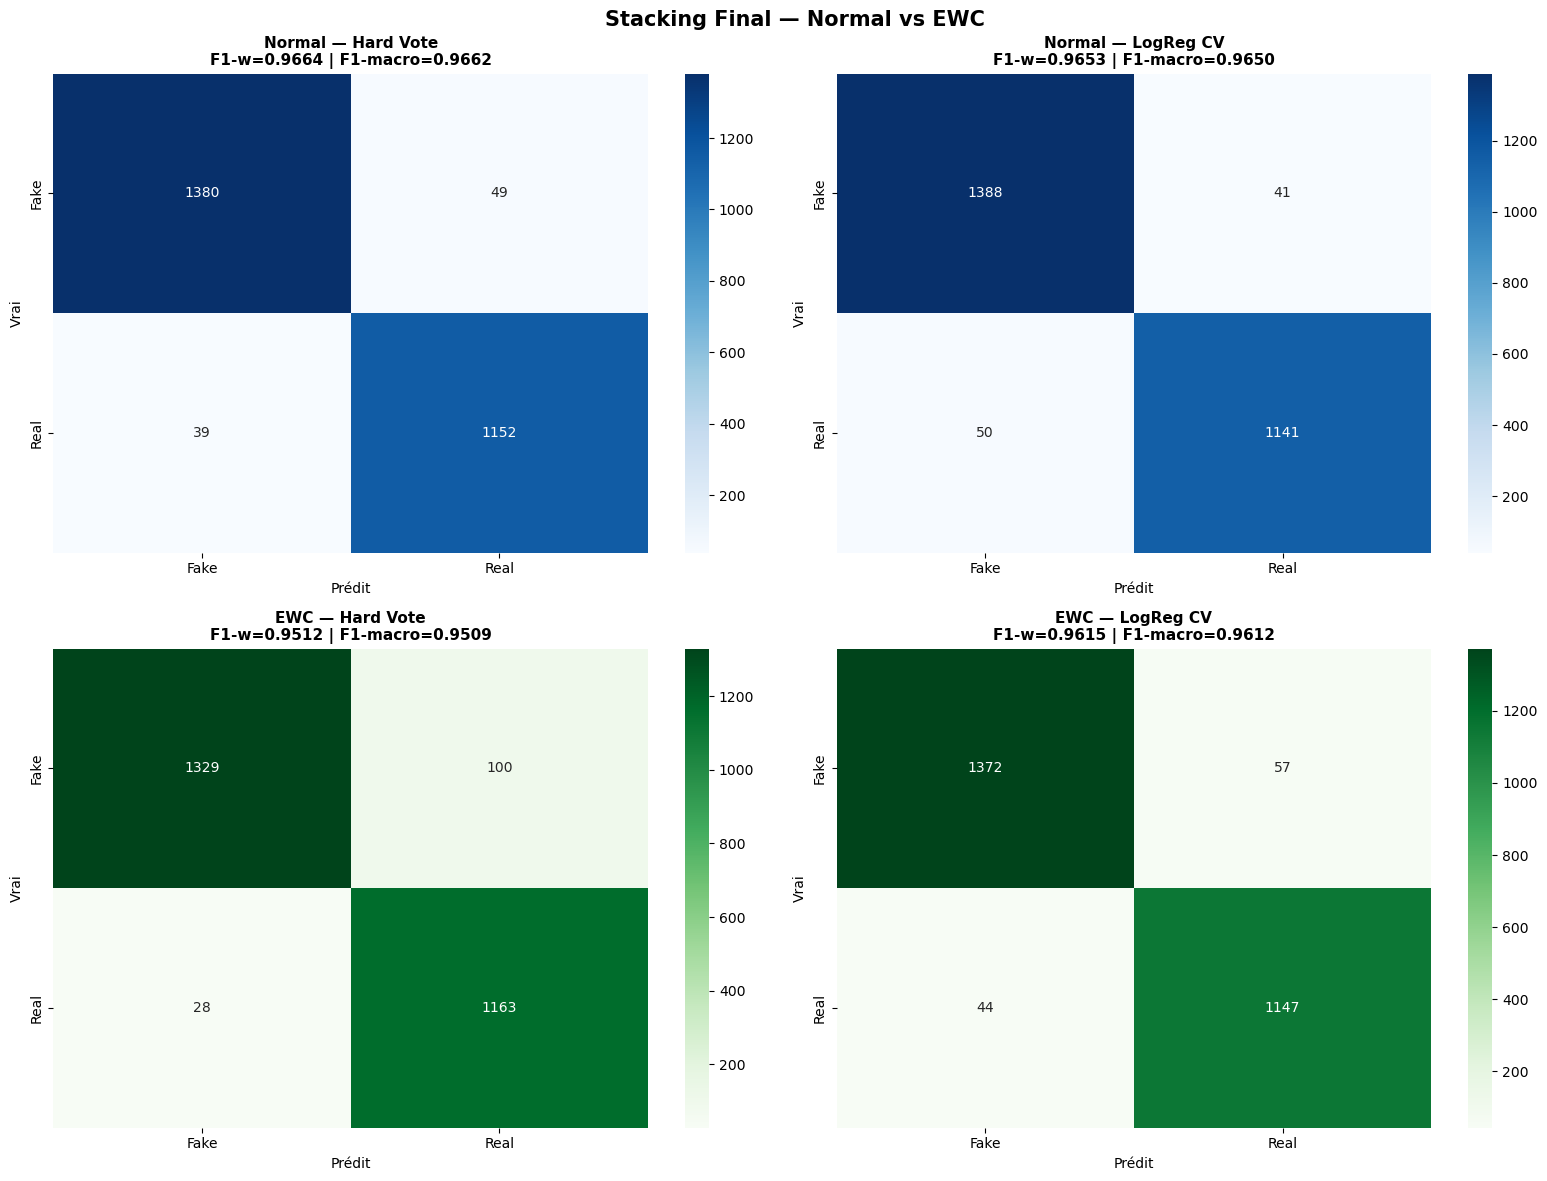

✅ Figure sauvegardée → ./ewc_corrected/comparison_normal_vs_ewc.png

=== Normal Hard Vote ===
              precision    recall  f1-score   support

        Real       0.96      0.97      0.96      1191
        Fake       0.97      0.97      0.97      1429

    accuracy                           0.97      2620
   macro avg       0.97      0.97      0.97      2620
weighted avg       0.97      0.97      0.97      2620


=== EWC Hard Vote ===
              precision    recall  f1-score   support

        Real       0.92      0.98      0.95      1191
        Fake       0.98      0.93      0.95      1429

    accuracy                           0.95      2620
   macro avg       0.95      0.95      0.95      2620
weighted avg       0.95      0.95      0.95      2620


=== Normal LogReg CV ===
              precision    recall  f1-score   support

        Real       0.97      0.96      0.96      1191
        Fake       0.97      0.97      0.97      1429

    accuracy                           

In [21]:
# ================================================================
# COMPARAISON FINALE — Normal vs EWC Hard Voting + LogReg
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression

EWC_DIR_CMP = './ewc_corrected'

# ── Charger prédictions EWC ───────────────────────────────────
rob_ewc   = np.load(f'{EWC_DIR_CMP}/roberta_ewc_preds_test.npy')
bart_ewc  = np.load(f'{EWC_DIR_CMP}/bart_ewc_preds_test.npy')
llama_ewc = np.load(f'{EWC_DIR_CMP}/llama_ewc_preds_test.npy')
labs_ewc  = np.load(f'{EWC_DIR_CMP}/roberta_ewc_labs_test.npy')

trans_ewc_hv = ((rob_ewc + bart_ewc + llama_ewc) >= 2).astype(int)

assert len(trans_ewc_hv) == len(y_true), \
    f'❌ Tailles différentes : EWC={len(trans_ewc_hv)} Normal={len(y_true)}'
assert np.array_equal(labs_ewc, y_true), '❌ Labels non alignés'
print(f'✅ Labels alignés — {len(y_true)} articles')

X_meta_ewc = np.stack([
    trans_ewc_hv.astype(float),
    gnn_hv[:len(trans_ewc_hv)].astype(float),
    rag_preds[:len(trans_ewc_hv)].astype(float)
], axis=1)

y_hard_ewc = (X_meta_ewc.sum(axis=1) >= 2).astype(int)

skf_ewc  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_ewc   = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                               class_weight={0:1.0, 1:2.0})
y_cv_ewc = cross_val_predict(lr_ewc, X_meta_ewc, y_true, cv=skf_ewc, method='predict')

print(f"\n{'='*70}")
print('  COMPARAISON FINALE — Pipeline Normal vs EWC')
print(f"{'='*70}")
print(f"{'Approche':<35} {'Acc':>7} {'F1-w':>7} {'F1-macro':>9} {'Recall':>8}")
print('─'*70)
for name, pred, labs in [
    ('Normal — Hard Vote 3 groupes',  y_hard,     y_true),
    ('Normal — LogReg CV 5-fold',     y_cv_pred,  y_true),
    ('EWC    — Hard Vote 3 groupes',  y_hard_ewc, y_true),
    ('EWC    — LogReg CV 5-fold',     y_cv_ewc,   y_true),
]:
    print(f'  {name:<33} {accuracy_score(labs,pred):>7.4f} '
          f'{f1_score(labs,pred,average="weighted"):>7.4f} '
          f'{f1_score(labs,pred,average="macro"):>9.4f} '
          f'{recall_score(labs,pred,average="weighted"):>8.4f}')
print('='*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stacking Final — Normal vs EWC', fontsize=15, fontweight='bold')

for ax, (title, pred, labs, cmap) in zip(axes.flat, [
    ('Normal — Hard Vote',  y_hard,     y_true, 'Blues'),
    ('Normal — LogReg CV',  y_cv_pred,  y_true, 'Blues'),
    ('EWC — Hard Vote',     y_hard_ewc, y_true, 'Greens'),
    ('EWC — LogReg CV',     y_cv_ewc,   y_true, 'Greens'),
]):
    cm = confusion_matrix(labs, pred, labels=[1, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    ax.set_title(f'{title}\nF1-w={f1_score(labs,pred,average="weighted"):.4f} | '
                 f'F1-macro={f1_score(labs,pred,average="macro"):.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')

plt.tight_layout()
plt.savefig(f'{EWC_DIR_CMP}/comparison_normal_vs_ewc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure sauvegardée → {EWC_DIR_CMP}/comparison_normal_vs_ewc.png')

for title, pred in [('Normal Hard Vote', y_hard), ('EWC Hard Vote', y_hard_ewc),
                    ('Normal LogReg CV', y_cv_pred), ('EWC LogReg CV', y_cv_ewc)]:
    print(f'\n=== {title} ===')
    print(classification_report(y_true, pred, target_names=['Real','Fake']))

In [22]:
import torch.nn as nn
from transformers import RobertaModel, AutoModel, AutoTokenizer, RobertaTokenizer

class FakeNewsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        hidden_size  = self.roberta.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 2)
        )
    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])

class BARTFakeNewsClassifier(nn.Module):
    def __init__(self, model_name='facebook/bart-base', unfreeze_last=1, dropout=0.4):
        super().__init__()
        self.bart = AutoModel.from_pretrained(model_name)
        hidden_size = self.bart.config.d_model
        for param in self.bart.parameters(): param.requires_grad = False
        for p in self.bart.encoder.layers[-unfreeze_last:]:
            for w in p.parameters(): w.requires_grad = True
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 2)
        )
    def forward(self, input_ids, attention_mask):
        out  = self.bart(input_ids=input_ids, attention_mask=attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.classifier(pooled)

print('✅ Architectures définies')

✅ Architectures définies


In [23]:
import torch, gc, numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

gc.collect(); torch.cuda.empty_cache()

# ── Test set 2620 ─────────────────────────────────────────────
df = pd.read_csv('./This_final.csv')
df['content_clean'] = df['content_clean'].fillna('').str.strip()
df = df[df['content_clean'] != ''].reset_index(drop=True)
_, temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
_, test_df = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])
test_texts  = test_df['content_clean'].tolist()
test_labels = test_df['label'].tolist()
print(f'Test set : {len(test_texts)} articles')

# ── RoBERTa ./ewc/ewc/ ────────────────────────────────────────
rob = FakeNewsClassifier().to(device)
rob.load_state_dict(torch.load('./ewc/ewc/roberta_ewc_best.pt',
                    map_location=device, weights_only=False))
rob.eval()
enc, labs, docs = tokenize_with_overlap(test_texts, test_labels)
loader = DataLoader(NewsDataset(enc, labs, docs), batch_size=32)
_, _, _, preds_rob, labs_arr = eval_roberta(rob, loader, device)
np.save('./ewc/ewc/roberta_ewc_preds_test_2620.npy', preds_rob)
np.save('./ewc/ewc/roberta_ewc_labs_test_2620.npy',  labs_arr)
print(f'RoBERTa F1: {f1_score(labs_arr, preds_rob, average="weighted"):.4f}')
del rob; gc.collect(); torch.cuda.empty_cache()

# ── BART ./ewc/ewc/ ───────────────────────────────────────────
bart = BARTFakeNewsClassifier().to(device)
bart.load_state_dict(torch.load('./ewc/ewc/bart_ewc_best.pt',
                     map_location=device, weights_only=False))
bart.eval()
enc_b, labs_b, docs_b = tokenize_bart_with_overlap(test_texts, test_labels)
loader_b = DataLoader(NewsDataset(enc_b, labs_b, docs_b), batch_size=16)
_, _, _, preds_bart, _ = eval_bart(bart, loader_b, device)
np.save('./ewc/ewc/bart_ewc_preds_test_2620.npy', preds_bart)
print(f'BART F1: {f1_score(labs_arr, preds_bart, average="weighted"):.4f}')
del bart; gc.collect(); torch.cuda.empty_cache()

print('✅ Preds sauvegardées dans ./ewc/ewc/ sur 2620 articles')

Test set : 2620 articles


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NameError: name 'tokenize_with_overlap' is not defined

Normal — HV: 0.9664 | LogReg: 0.9653
✅ Labels alignés — 2620 articles
EWC    — HV: 0.9512 | LogReg: 0.9615

  COMPARAISON FINALE — Pipeline Normal vs EWC
  Approche                                Acc    F1-w  F1-macro   Recall
  ────────────────────────────────────────────────────────────────────
  Normal — Hard Vote 3 groupes         0.9664  0.9664    0.9662   0.9664
  Normal — LogReg CV 5-fold            0.9653  0.9653    0.9650   0.9653
  EWC    — Hard Vote 3 groupes         0.9511  0.9512    0.9509   0.9511
  EWC    — LogReg CV 5-fold            0.9615  0.9615    0.9612   0.9615


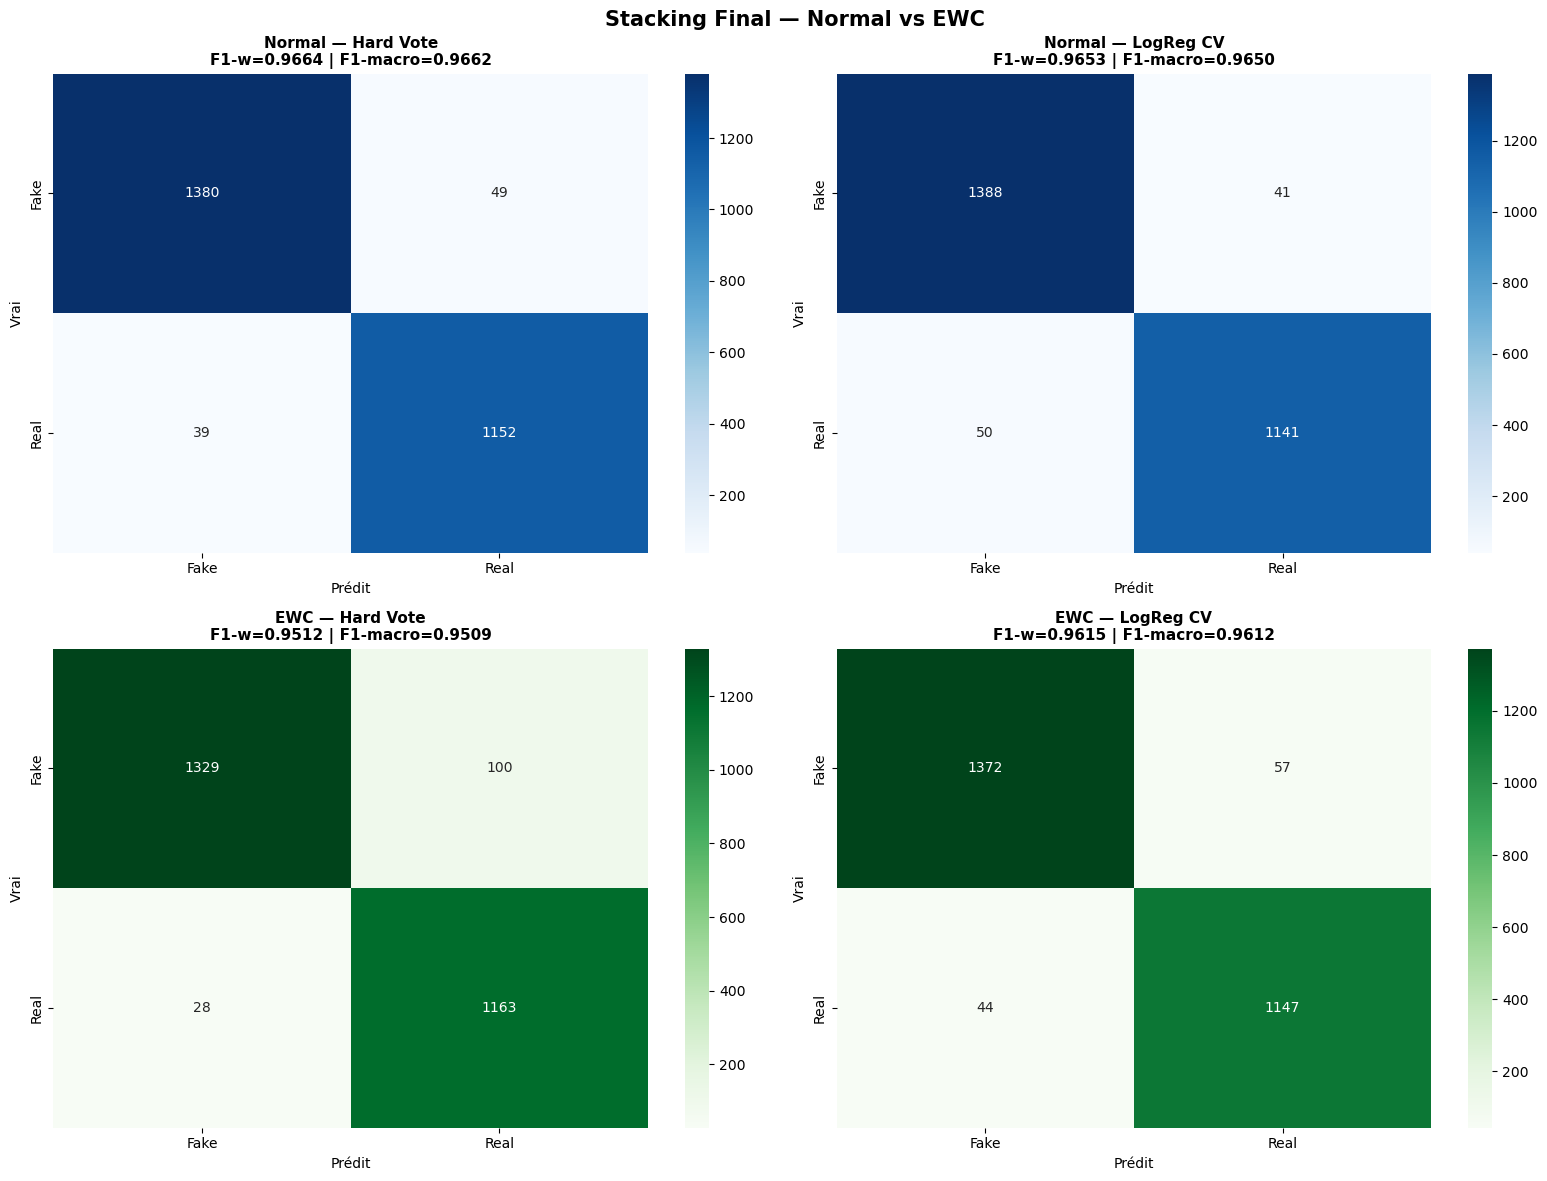

✅ Figure sauvegardée → ./ewc_corrected/comparison_normal_vs_ewc_final.png

=== Normal Hard Vote ===
              precision    recall  f1-score   support

        Real       0.96      0.97      0.96      1191
        Fake       0.97      0.97      0.97      1429

    accuracy                           0.97      2620
   macro avg       0.97      0.97      0.97      2620
weighted avg       0.97      0.97      0.97      2620


=== Normal LogReg CV ===
              precision    recall  f1-score   support

        Real       0.97      0.96      0.96      1191
        Fake       0.97      0.97      0.97      1429

    accuracy                           0.97      2620
   macro avg       0.97      0.96      0.96      2620
weighted avg       0.97      0.97      0.97      2620


=== EWC Hard Vote ===
              precision    recall  f1-score   support

        Real       0.92      0.98      0.95      1191
        Fake       0.98      0.93      0.95      1429

    accuracy                     

In [25]:
# ================================================================
# COMPARAISON FINALE — Normal vs EWC (depuis fichiers .npy)
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, gc
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

gc.collect()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Charger prédictions NORMAL ────────────────────────────────
y_true   = np.load('./models_v3/hard_voting_trans_labs.npy')
trans_hv = np.load('./models_v3/hard_voting_final.npy')
gnn_hv   = np.load('./mode/hard_voting_gnns.npy')
rag_p    = np.load('./ewc/ewc/rag_preds_test.npy')

N = min(len(trans_hv), len(gnn_hv), len(rag_p), len(y_true))
y_true   = y_true[:N]
X_normal = np.stack([trans_hv[:N].astype(float),
                     gnn_hv[:N].astype(float),
                     rag_p[:N].astype(float)], axis=1)
y_hard   = (X_normal.sum(axis=1) >= 2).astype(int)
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr       = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight={0:1.0,1:2.0})
y_cv     = cross_val_predict(lr, X_normal, y_true, cv=skf, method='predict')
print(f'Normal — HV: {f1_score(y_true,y_hard,average="weighted"):.4f} | LogReg: {f1_score(y_true,y_cv,average="weighted"):.4f}')

# ── Charger prédictions EWC (ewc_corrected = 2620 articles) ──
rob_ewc   = np.load('./ewc_corrected/roberta_ewc_preds_test.npy')
bart_ewc  = np.load('./ewc_corrected/bart_ewc_preds_test.npy')
llama_ewc = np.load('./ewc_corrected/llama_ewc_preds_test.npy')
labs_ewc  = np.load('./ewc_corrected/roberta_ewc_labs_test.npy')

assert np.array_equal(labs_ewc, y_true), '❌ Labels non alignés'
print(f'✅ Labels alignés — {N} articles')

trans_ewc_hv = ((rob_ewc + bart_ewc + llama_ewc) >= 2).astype(int)
X_ewc        = np.stack([trans_ewc_hv.astype(float),
                          gnn_hv[:N].astype(float),
                          rag_p[:N].astype(float)], axis=1)
y_hard_ewc   = (X_ewc.sum(axis=1) >= 2).astype(int)
skf_ewc      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_ewc       = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight={0:1.0,1:2.0})
y_cv_ewc     = cross_val_predict(lr_ewc, X_ewc, y_true, cv=skf_ewc, method='predict')
print(f'EWC    — HV: {f1_score(y_true,y_hard_ewc,average="weighted"):.4f} | LogReg: {f1_score(y_true,y_cv_ewc,average="weighted"):.4f}')

# ── Tableau comparatif ────────────────────────────────────────
print(f"\n{'='*72}")
print('  COMPARAISON FINALE — Pipeline Normal vs EWC')
print(f"{'='*72}")
print(f"  {'Approche':<35} {'Acc':>7} {'F1-w':>7} {'F1-macro':>9} {'Recall':>8}")
print('  ' + '─'*68)
for name, pred in [
    ('Normal — Hard Vote 3 groupes',  y_hard),
    ('Normal — LogReg CV 5-fold',     y_cv),
    ('EWC    — Hard Vote 3 groupes',  y_hard_ewc),
    ('EWC    — LogReg CV 5-fold',     y_cv_ewc),
]:
    print(f'  {name:<35} {accuracy_score(y_true,pred):>7.4f} '
          f'{f1_score(y_true,pred,average="weighted"):>7.4f} '
          f'{f1_score(y_true,pred,average="macro"):>9.4f} '
          f'{recall_score(y_true,pred,average="weighted"):>8.4f}')
print(f"{'='*72}")

# ── Figure 2x2 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stacking Final — Normal vs EWC', fontsize=15, fontweight='bold')
for ax, (title, pred, cmap) in zip(axes.flat, [
    ('Normal — Hard Vote',  y_hard,     'Blues'),
    ('Normal — LogReg CV',  y_cv,       'Blues'),
    ('EWC — Hard Vote',     y_hard_ewc, 'Greens'),
    ('EWC — LogReg CV',     y_cv_ewc,   'Greens'),
]):
    cm = confusion_matrix(y_true, pred, labels=[1,0])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    ax.set_title(f'{title}\nF1-w={f1_score(y_true,pred,average="weighted"):.4f} | '
                 f'F1-macro={f1_score(y_true,pred,average="macro"):.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.tight_layout()
plt.savefig('./ewc_corrected/comparison_normal_vs_ewc_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée → ./ewc_corrected/comparison_normal_vs_ewc_final.png')

# ── Classification reports ────────────────────────────────────
for title, pred in [('Normal Hard Vote', y_hard), ('Normal LogReg CV', y_cv),
                    ('EWC Hard Vote', y_hard_ewc), ('EWC LogReg CV', y_cv_ewc)]:
    print(f'\n=== {title} ===')
    print(classification_report(y_true, pred, target_names=['Real','Fake']))

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')